[INFO] Min common length = 119


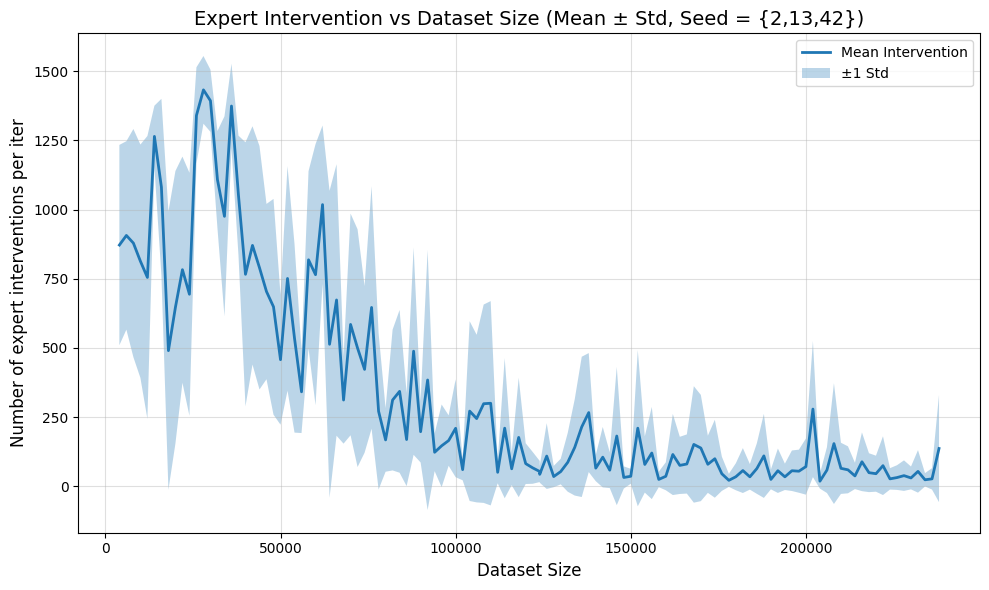

In [17]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt


def plot_nswitch_from_checkpoints(checkpoint_roots):

    all_nswitches = []
    all_dataset_sizes = []

    # --------------------------------
    # Load all results first
    # --------------------------------
    for root in checkpoint_roots:
        result_path = os.path.join(root, "results.json")

        if not os.path.exists(result_path):
            raise FileNotFoundError(f"results.json not found: {result_path}")

        with open(result_path, "r") as f:
            results = json.load(f)

        dataset_sizes = np.array(results["dataset_sizes"])
        nswitches = np.array(results["nswitches"])

        all_dataset_sizes.append(dataset_sizes)
        all_nswitches.append(nswitches)

    # --------------------------------
    # Find minimum length
    # --------------------------------
    min_len = min(len(x) for x in all_nswitches)
    print(f"[INFO] Min common length = {min_len}")

    # --------------------------------
    # Crop to minimum length
    # --------------------------------
    all_nswitches = [x[:min_len] for x in all_nswitches]
    all_dataset_sizes = [x[:min_len] for x in all_dataset_sizes]

    # reference x-axis (첫 번째 실험 기준)
    dataset_sizes_ref = all_dataset_sizes[0]

    # stack: (N, min_len)
    all_nswitches = np.stack(all_nswitches, axis=0)

    # --------------------------------
    # Mean / Std
    # --------------------------------
    mean_nswitch = np.mean(all_nswitches, axis=0)
    std_nswitch  = np.std(all_nswitches, axis=0)

    # --------------------------------
    # Plot
    # --------------------------------
    plt.figure(figsize=(10, 6))

    plt.plot(dataset_sizes_ref, mean_nswitch,
             linewidth=2,
             label="Mean Intervention")

    plt.fill_between(
        dataset_sizes_ref,
        mean_nswitch - std_nswitch,
        mean_nswitch + std_nswitch,
        alpha=0.3,
        label="±1 Std"
    )

    plt.xlabel("Dataset Size", fontsize=12)
    plt.ylabel("Number of expert interventions per iter", fontsize=12)
    plt.title("Expert Intervention vs Dataset Size (Mean ± Std, Seed = {2,13,42})", fontsize=14)

    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


checkpoint_dirs = [
    "/AILAB-summer-school-2025/RND/checkpoints/[Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.7_minDemo70_H0_FTrue",
    "/AILAB-summer-school-2025/RND/checkpoints/[Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed2",
    "/AILAB-summer-school-2025/RND/checkpoints/[Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed13"
]

plot_nswitch_from_checkpoints(checkpoint_dirs)
